# Searching pointcloud.org with `pystac-client`

[pointcloud.org](https://pointcloud.org) is a public archive of lidar point clouds,
every dataset described as [STAC](https://stacspec.org/) and stored as
[COPC](https://copc.io) — a LAZ variant you can read a piece of over HTTP without
downloading the whole file.

This notebook uses [`pystac-client`](https://pystac-client.readthedocs.io/), the
reference Python STAC client, against the archive's `/search` endpoint. Everything
here is a live query — no credentials, no signup, no download until you ask for one.

**What you'll do:** open the API, list what's in it, filter by space, time and point
count, then pull a real COPC URL out of the results and read actual points out of the
file — without ever fetching the whole thing.

It runs unchanged in three places: locally, in
[**JupyterLite in your browser**](https://pointcloud.org/lite/) with no Python
installed at all, and in any hosted notebook service. The few lines that differ
between a browser and a desktop are marked where they appear.


## Setup

Everything from PyPI:

- **`pystac-client`** — the STAC client itself, used throughout.
- **`laspy`** + **`lazrs`** — reads COPC files, including straight over HTTPS. `lazrs`
  is the LAZ decompressor; without it laspy can read the header but not the points.
- **`duckdb`** + **`pandas`** — for the bulk section, querying the archive's
  GeoParquet in place. DuckDB's `.df()` hands results to pandas, and pandas is not
  installed for you in the browser.
- **`matplotlib`** — to draw the points we read.
- **`pyodide-http`** — only used in the browser, where it routes Python's HTTP
  through the browser's own fetch. Installs and sits idle everywhere else.


In [1]:
%pip install --quiet pystac-client laspy lazrs duckdb pandas matplotlib pyodide-http


Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import sys
import urllib.request

# Pyodide reports itself as the emscripten platform -- that, not the mere presence
# of a package, is what tells us we are in a browser. There are no sockets there, so
# Python's HTTP has to go through the browser itself; pyodide_http.patch_all()
# redirects urllib and requests to do exactly that.
IN_BROWSER = sys.platform == "emscripten"
if IN_BROWSER:
    import pyodide_http

    pyodide_http.patch_all()

import duckdb
import laspy
import matplotlib
import pystac
import pystac_client

# Cloudflare sits in front of the archive and rejects Python's default urllib
# User-Agent with a 403, so the raw requests in this notebook set one. In the
# browser we send nothing: the browser supplies its own and refuses to let
# JavaScript override it.
HEADERS = {} if IN_BROWSER else {"User-Agent": "pointcloud-org-quickstart"}


def fetch(url, headers=None):
    """GET a URL and return the bytes."""
    request = urllib.request.Request(url, headers={**HEADERS, **(headers or {})})
    with urllib.request.urlopen(request) as response:
        return response.read()


print("running in the browser:", IN_BROWSER)
print("pystac-client", pystac_client.__version__)
print("pystac       ", pystac.__version__)
print("laspy        ", laspy.__version__, laspy.LazBackend.detect_available())
print("duckdb       ", duckdb.__version__)


running in the browser: False
pystac-client 0.9.0
pystac        1.15.2
laspy         2.7.0 (<LazBackend.LazrsParallel: 0>, <LazBackend.Lazrs: 1>)
duckdb        1.5.5


## 1. Open the API

`Client.open()` fetches the landing page and reads its `conformsTo` list, which is
how the client decides what it's allowed to do — whether it can search at all,
whether it can use CQL2 filters, and so on.

In [3]:
from pystac_client import Client

API = "https://pointcloud.org/stac"
client = Client.open(API)

print(f"{client.id}  —  {client.title}")
print()
for uri in sorted(client.get_conforms_to()):
    print(" ", uri)

pointcloud-org  —  pointcloud.org STAC API

  http://www.opengis.net/spec/cql2/1.0/conf/advanced-comparison-operators
  http://www.opengis.net/spec/cql2/1.0/conf/basic-cql2
  http://www.opengis.net/spec/cql2/1.0/conf/cql2-json
  http://www.opengis.net/spec/cql2/1.0/conf/cql2-text
  http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/core
  http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/geojson
  http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/oas30
  http://www.opengis.net/spec/ogcapi-features-3/1.0/conf/features-filter
  http://www.opengis.net/spec/ogcapi-features-3/1.0/conf/filter
  https://api.stacspec.org/v1.0.0/collections
  https://api.stacspec.org/v1.0.0/core
  https://api.stacspec.org/v1.0.0/item-search
  https://api.stacspec.org/v1.0.0/item-search#filter
  https://api.stacspec.org/v1.0.0/ogcapi-features


## 2. What's in the archive?

Each dataset is a STAC **Collection**; each file within it is an **Item**. Most
datasets here hold a single Item, since one lidar project is usually published as
one COPC file.

In [4]:
collections = list(client.get_collections())
print(f"{len(collections)} collections\n")

for c in collections[:8]:
    interval = c.extent.temporal.intervals[0]
    when = interval[0].date().isoformat() if interval[0] else "unknown"
    print(f"  {c.id:28} {when}  {c.title}")
print(f"  ... and {len(collections) - 8} more")

53 collections

  autzen                       2010-06-23  Autzen Stadium
  autzen-2023                  2023-07-21  Autzen Stadium — Willamette Valley 2023 Lidar
  barringer-meteorite-crater   2010-03-12  Barringer Meteorite Crater
  chicago-downtown             2017-04-16  Chicago Downtown
  copenhagen-kastellet         2023-07-12  Copenhagen Kastellet
  IA_Eastern_1_2019            2019-12-10  IA Eastern 1 2019 Lidar
  IA_Eastern_2_2019            2019-12-07  IA Eastern 2 2019 Lidar
  IA_Eastern_3_2019            2019-12-08  IA Eastern 3 2019 Lidar
  ... and 45 more


## 3. Your first search

`search()` builds the query; nothing is sent until you iterate. `max_items` caps how
much the client will page through, which is what you want while exploring.

In [5]:
search = client.search(max_items=5)

for item in search.items():
    props = item.properties
    print(f"{item.id[:40]:42} {props.get('pc:count', 0):>16,} points")

autzen-classified                                10,653,336 points
autzen-2023                                      21,233,219 points
barringer-meteorite-crater-ncalm-2010-10        185,455,845 points
chicago-downtown                                 30,332,651 points
copenhagen-kastellet                             33,518,244 points


## 4. Search by space

`bbox` takes `[west, south, east, north]` in WGS84 degrees.

One caveat worth knowing: this API implements spatial filtering as a **bounding-box
intersection**, not true geometry intersection. A result's footprint is guaranteed to
overlap your box, but for an irregular footprint the box may overlap where the actual
points do not. For precise work, intersect `item.geometry` yourself.

In [6]:
# Roughly the state of Oregon
oregon = [-124.6, 41.9, -116.4, 46.3]

for item in client.search(bbox=oregon).items():
    print(f"{item.id:26} {item.collection_id:20} {item.bbox}")

autzen-classified          autzen               [-123.0755365, 44.04973358, -123.0619606, 44.06277128]
autzen-2023                autzen-2023          [-123.0741187, 44.05008109, -123.0619959, 44.06679313]


## 5. Search by time

`datetime` accepts a single instant, a closed interval, or an open one (`"2020-01-01/.."`).

Note that many datasets in this archive describe a survey that spans weeks, so they
carry `start_datetime`/`end_datetime` and a null `datetime`. The API matches on the
instant where there is one; the two-bound form is what a range search needs.

In [7]:
recent = client.search(datetime="2019-01-01/2021-12-31")
items = list(recent.items())
print(f"{len(items)} items acquired 2019–2021\n")

for item in items[:6]:
    p = item.properties
    when = p.get("datetime") or f"{p.get('start_datetime')} … {p.get('end_datetime')}"
    print(f"  {item.id[:30]:32} {when}")

21 items acquired 2019–2021

  IA_Eastern_1_2019                2019-12-10T00:00:00Z
  IA_Eastern_2_2019                2019-12-07T00:00:00Z
  IA_Eastern_3_2019                2019-12-08T00:00:00Z
  IA_NorthCentral_1_2020           2020-04-04T00:00:00Z
  IA_NorthCentral_2_2020           2020-04-16T00:00:00Z
  IA_NorthCentral_3_2020           2020-04-04T00:00:00Z


## 6. Search by anything else, with CQL2

The interesting queries for point clouds are about the *points*: how many, what kind,
what coordinate system. Those live in Item properties from the
[Point Cloud](https://github.com/stac-extensions/pointcloud) and
[Projection](https://github.com/stac-extensions/projection) STAC extensions, and CQL2
can filter on them.

`/queryables` tells you which properties are filterable and what type each one is.

In [8]:
import json

queryables = json.loads(fetch(f"{API}/queryables"))
for name, schema in list(queryables["properties"].items()):
    print(f"  {name:22} {schema.get('type', schema.get('format', ''))}")


  id                     string
  collection             string
  datetime               string
  start_datetime         string
  end_datetime           string
  title                  string
  pc:count               integer
  pc:schemas             string
  pc:statistics          string
  pc:type                string
  proj:epsg              string
  proj:bbox              string
  proj:geometry          string
  proj:projjson          string
  proj:wkt2              string
  stac_extensions        string
  stac_version           string
  geometry               string
  geometry_bbox          string
  bbox                   string
  links                  string
  assets                 string


In [9]:
# Datasets with more than five billion points
big = client.search(
    filter_lang="cql2-json",
    filter={"op": ">", "args": [{"property": "pc:count"}, 5_000_000_000]},
)
items = sorted(big.items(), key=lambda i: -i.properties["pc:count"])
print(f"{len(items)} datasets over 5 billion points\n")
for item in items[:8]:
    print(f"  {item.id[:34]:36} {item.properties['pc:count']:>16,}")

39 datasets over 5 billion points

  MN_RainyLake_1_2020                   355,339,247,767
  MN_UpperMissRiver_6_B22               325,278,739,823
  MN_RainyLake_2_2020                   293,472,666,706
  MN_RiverWest_1_B23                    288,918,266,196
  MN_RiverWest_2_B23                    264,904,992,691
  MN_CentralMissRiver_4_B22             215,065,503,920
  MN_UpperMissRiver_5_B22               200,558,106,069
  MN_GoodhueCo_1_2020                   183,448,445,150


CQL2 also has a text form, which is easier to type by hand and equally valid:

In [10]:
query = "pc:count BETWEEN 40000000000 AND 100000000000"
mid = list(client.search(filter_lang="cql2-text", filter=query).items())
print(f"{len(mid)} datasets between 40 and 100 billion points")
for item in mid[:5]:
    print(f"  {item.id[:34]:36} {item.properties['pc:count']:>16,}")

23 datasets between 40 and 100 billion points
  IA_Eastern_2_2019                      90,121,793,878
  IA_Eastern_3_2019                      99,896,983,309
  IA_NorthCentral_1_2020                 49,774,341,127
  IA_NorthCentral_2_2020                 60,040,043,143
  IA_NorthCentral_3_2020                 71,831,674,676


Filters combine, so you can ask a real question — *large surveys in Minnesota,
acquired since 2020* — in one query:

In [11]:
combined = client.search(
    # Minnesota, give or take: this box also clips the northern edge of Iowa, and
    # you can see that in the results -- the bbox approximation from section 4 in
    # practice.
    bbox=[-97.3, 43.4, -89.4, 49.4],
    datetime="2020-01-01/..",
    filter_lang="cql2-json",
    filter={"op": ">", "args": [{"property": "pc:count"}, 50_000_000_000]},
)
for item in combined.items():
    print(f"  {item.id:28} {item.properties['pc:count']:>16,}")

  IA_Western_2_2020              78,997,864,806
  MN_BeckerCo_1_2021             97,225,507,932
  MN_CentralMissRiver_1_B22      58,846,044,528
  MN_CentralMissRiver_2_B22      94,449,189,320
  MN_CentralMissRiver_3_B22     102,390,618,633
  MN_CentralMissRiver_4_B22     215,065,503,920
  MN_CentralMissRiver_5_B22      83,069,293,873
  MN_CentralMissRiver_6_B22      85,796,446,582
  MN_GoodhueCo_1_2020           183,448,445,150
  MN_LakeSuperior_1_2021         98,942,509,604


  MN_LakeSuperior_2_2021        179,028,497,838
  MN_MORiverBigSioux_1_B21       91,332,165,862
  MN_RainyLake_1_2020           355,339,247,767
  MN_RainyLake_2_2020           293,472,666,706
  MN_RiverEast_1_B23             70,023,749,514
  MN_RiverWest_1_B23            288,918,266,196
  MN_RiverWest_2_B23            264,904,992,691
  MN_RiverWest_3_B23            104,729,861,220
  MN_SEDriftless_1_2021          61,930,563,511
  MN_SEDriftless_2_2021         102,364,344,101


  MN_SEDriftless_3_2021          67,476,190,327
  MN_SEDriftless_4_2021          73,144,772,767
  MN_SEDriftless_5_2021          80,744,226,841
  MN_UpperMissRiver_2_B22       180,708,720,683
  MN_UpperMissRiver_4_B22       180,298,113,067
  MN_UpperMissRiver_5_B22       200,558,106,069
  MN_UpperMissRiver_6_B22       325,278,739,823


## 7. Inside an Item

An Item carries the metadata you need to decide whether to download anything: how many
points, what classification schema, which coordinate reference system, and the asset
URL itself.

In [12]:
item = next(client.search(collections=["autzen"]).items())

print(item.id, "in", item.collection_id)
print()
print("assets:")
for key, asset in item.assets.items():
    print(f"  {key:12} {asset.media_type}")
    print(f"               {asset.href}")
print()
p = item.properties
print("points        :", f"{p['pc:count']:,}")
print("type          :", p.get("pc:type"))
print("CRS (EPSG)    :", p.get("proj:epsg"))
print("dimensions    :", ", ".join(s["name"] for s in p.get("pc:schemas", []))[:90])

autzen-classified in autzen

assets:
  data         application/vnd.laszip+copc
               https://data.pointcloud.org/autzen/autzen-classified.copc.laz
  thumbnail    image/png
               https://data.pointcloud.org/autzen/stac/hero.png

points        : 10,653,336
type          : lidar
CRS (EPSG)    : None
dimensions    : X, Y, Z, Intensity, ReturnNumber, NumberOfReturns, ScanDirectionFlag, EdgeOfFlightLine, Cl


## 8. Read the points without downloading the file

This is what COPC is for. The format organizes points into an octree, so a reader can
fetch just the nodes covering the area and the level of detail it wants, over ordinary
HTTP range requests. `item.assets["data"].href` is a plain HTTPS URL — nothing to sign,
nothing to mount.

`laspy`'s `CopcReader` takes that URL directly. Opening it reads only the header and
the octree index.

The one browser difference in this notebook: laspy's own HTTP source fans its range
requests out across threads, and there are no threads in the browser, so there we hand
`CopcReader` a small serial file-like object instead. Same requests, one at a time.


In [13]:
import numpy as np
from laspy import CopcReader
from laspy.copc import Bounds


class RangeReader:
    """Serial seek/read file object over HTTP range requests.

    Only needed in the browser -- laspy's built-in HTTP source uses a thread pool,
    which Pyodide has no threads for. `CopcReader` accepts any file-like object, so
    this stands in: same range requests, issued one at a time.
    """

    def __init__(self, url):
        self.url = url
        self.pos = 0

    def seek(self, pos, whence=0):
        assert whence == 0, "only absolute seeks"
        self.pos = pos

    def tell(self):
        return self.pos

    def read(self, n):
        if n == 0:
            return b""
        end = self.pos + n - 1
        data = fetch(self.url, {"Range": f"bytes={self.pos}-{end}"})
        self.pos += n
        return data

    def close(self):
        pass


href = item.assets["data"].href
print("COPC URL:", href)

source = RangeReader(href) if IN_BROWSER else href
reader = CopcReader.open(source)
hdr = reader.header
print()
print("points in file :", f"{hdr.point_count:,}")
print("point format   :", hdr.point_format.id, "-", ", ".join(
    d.name for d in hdr.point_format.dimensions)[:70], "...")
print("bounds (native):", [round(float(v), 1) for v in hdr.mins], "→", [round(float(v), 1) for v in hdr.maxs])


COPC URL: https://data.pointcloud.org/autzen/autzen-classified.copc.laz



points in file : 10,653,336
point format   : 7 - X, Y, Z, intensity, return_number, number_of_returns, synthetic, key_p ...
bounds (native): [635577.8, 848882.2, 406.1] → [639003.7, 853537.7, 615.3]


### Filter by resolution

`query(resolution=...)` stops descending the octree once the node spacing is finer
than the value you give, in the file's own units (feet here). It is the cheap way to
get a representative sample of the whole footprint: coarse levels only, so only a
fraction of the nodes are fetched.

Watch the point count fall as the resolution gets coarser — that is bytes not
transferred.

In [14]:
for resolution in (60.0, 30.0, 10.0):
    pts = reader.query(resolution=resolution)
    share = len(pts) / hdr.point_count
    print(f"  resolution {resolution:>5} ft → {len(pts):>10,} points  ({share:6.2%} of the file)")

  resolution  60.0 ft →     61,201 points  ( 0.57% of the file)


  resolution  30.0 ft →    131,060 points  ( 1.23% of the file)


  resolution  10.0 ft →    577,637 points  ( 5.42% of the file)


### Filter by bounds

`query(bounds=...)` restricts the read spatially. Coordinates are in the file's own
CRS, so derive them from the header rather than guessing — here, the middle fifth of
the footprint.

`Bounds` is three-dimensional, and that matters: narrow the Z range along with X and Y
and you will slice away the ground and most of what is above it. Keep the header's full
Z extent unless you actually want an elevation band.

In [15]:
span = hdr.maxs - hdr.mins
middle = Bounds(
    mins=np.array([hdr.mins[0] + span[0] * 0.40, hdr.mins[1] + span[1] * 0.40, hdr.mins[2]]),
    maxs=np.array([hdr.mins[0] + span[0] * 0.60, hdr.mins[1] + span[1] * 0.60, hdr.maxs[2]]),
)

sub = reader.query(bounds=middle)
print(f"middle 20% of the footprint (full elevation range): {len(sub):,} points")
print(f"{len(sub) / hdr.point_count:.2%} of the file — and only the octree nodes covering that window were fetched")

middle 20% of the footprint (full elevation range): 364,889 points
3.43% of the file — and only the octree nodes covering that window were fetched


### Look at them

The two filters compose, which is what makes this practical: a coarse read of the
whole footprint to see the shape of the thing, and a full-resolution read of one
small area to see detail. Below, both — colored by elevation, and by the
classification codes a human assigned to this dataset.

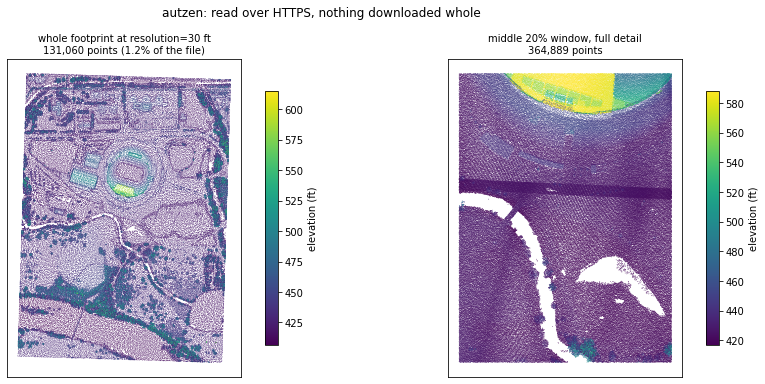

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Modest raster size on purpose: this notebook is committed with its outputs, and a
# dense scatter of several hundred thousand points can weigh more than a megabyte.
plt.rcParams["figure.dpi"] = 72

OVERVIEW_RES = 30.0
overview = reader.query(resolution=OVERVIEW_RES)
detail = reader.query(bounds=middle)
draw = detail[::2]                      # every other point, for drawing only

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

ax = axes[0]
s = ax.scatter(overview.x, overview.y, c=overview.z, s=0.5, cmap="viridis", linewidths=0)
ax.set_title(f"whole footprint at resolution={OVERVIEW_RES:g} ft\n{len(overview):,} points "
             f"({len(overview)/hdr.point_count:.1%} of the file)", fontsize=10)
fig.colorbar(s, ax=ax, label="elevation (ft)", shrink=0.8)

ax = axes[1]
s = ax.scatter(draw.x, draw.y, c=draw.z, s=0.5, cmap="viridis", linewidths=0)
ax.set_title(f"middle 20% window, full detail\n{len(detail):,} points", fontsize=10)
fig.colorbar(s, ax=ax, label="elevation (ft)", shrink=0.8)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{item.collection_id}: read over HTTPS, nothing downloaded whole", y=0.98)
plt.tight_layout()
plt.show()

### Classification

This dataset was hand-classified, so every point carries an
[ASPRS class](https://www.asprs.org/wp-content/uploads/2019/07/LAS_1_4_r15.pdf) code.
Naming the handful of codes that matter, rather than throwing the raw integers at a
continuous colormap, is what makes the structure legible — ground separates from
canopy, and the stadium separates from both.

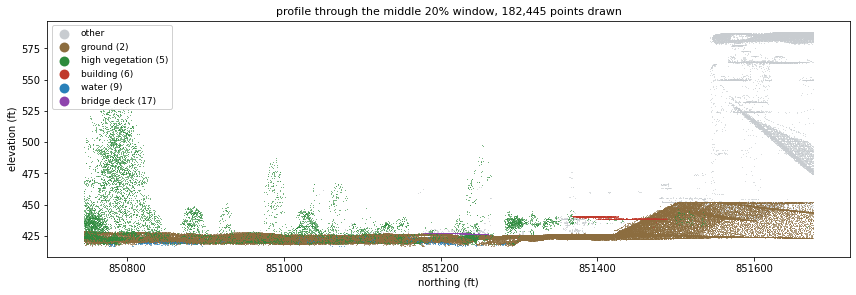

classification breakdown of the window:
  class  2 ground               300,553  (82.37%)
  class  0 unnamed               38,978  (10.68%)
  class  5 high vegetation       17,878  ( 4.90%)
  class  6 building               3,961  ( 1.09%)
  class 17 bridge deck            1,238  ( 0.34%)
  class 19 unnamed                  973  ( 0.27%)
  class  9 water                    752  ( 0.21%)
  class 65 unnamed                  326  ( 0.09%)


In [17]:
CLASSES = {
    2:  ("#8c6d3f", "ground"),
    5:  ("#2e8b3d", "high vegetation"),
    4:  ("#66bb5a", "medium vegetation"),
    3:  ("#a5d6a0", "low vegetation"),
    6:  ("#c0392b", "building"),
    9:  ("#2980b9", "water"),
    17: ("#8e44ad", "bridge deck"),
}

def plot_classified(ax, xs, ys, classes):
    """Scatter per class so matplotlib builds a real legend, with everything
    unnamed drawn once in grey underneath."""
    known = np.isin(classes, list(CLASSES))
    ax.scatter(xs[~known], ys[~known], s=0.5, c="#c8ccd0", linewidths=0, label="other")
    for code, (color, label) in CLASSES.items():
        m = classes == code
        if m.any():
            ax.scatter(xs[m], ys[m], s=0.5, c=color, linewidths=0, label=f"{label} ({code})")

fig, ax = plt.subplots(figsize=(12, 4.2))
plot_classified(ax, draw.y, draw.z, draw.classification)
ax.set_xlabel("northing (ft)"); ax.set_ylabel("elevation (ft)")
ax.set_title(f"profile through the middle 20% window, {len(draw):,} points drawn", fontsize=11)
leg = ax.legend(markerscale=14, fontsize=9, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

classes, counts = np.unique(detail.classification, return_counts=True)
print("classification breakdown of the window:")
for code, n in sorted(zip(classes.tolist(), counts.tolist()), key=lambda t: -t[1])[:8]:
    label = CLASSES.get(code, ("", "unnamed"))[1]
    print(f"  class {code:>2} {label:<18} {n:>9,}  ({n / len(detail):6.2%})")

## 9. Bulk queries: skip the API entirely

The API is convenient for a handful of results. For anything analytical — *every*
dataset's point count, grouped and aggregated — the archive also publishes its whole
catalog as a single
[STAC-GeoParquet](https://github.com/stac-utils/stac-geoparquet) file.

It is a few hundred kilobytes, so the simplest thing that works everywhere is to
fetch it once and let DuckDB query the local copy. (DuckDB can also read it in place
over HTTP with its `httpfs` extension — but not in the browser, where there are no
sockets for it to use.)

This is the same data `/search` reads, so the two never disagree.


In [18]:
PARQUET_URL = "https://data.pointcloud.org/stac/items.parquet"
LOCAL_PARQUET = "items.parquet"

blob = fetch(PARQUET_URL)
with open(LOCAL_PARQUET, "wb") as fh:
    fh.write(blob)
print(f"{len(blob):,} bytes of STAC-GeoParquet — the entire archive's metadata")

con = duckdb.connect()
# DuckDB renders TIMESTAMPTZ in the session's timezone; pin it to UTC so these
# values read the same as the API's.
con.execute("SET TimeZone='UTC'")

df = con.execute(f"""
    SELECT collection,
           "pc:count" AS points,
           CAST(datetime AS VARCHAR) AS acquired
    FROM read_parquet('{LOCAL_PARQUET}')
    ORDER BY points DESC
    LIMIT 8
""").df()
print()
print(df.to_string(index=False))


450,218 bytes of STAC-GeoParquet — the entire archive's metadata



               collection       points               acquired
      MN_RainyLake_1_2020 355339247767 2021-04-16 00:00:00+00
  MN_UpperMissRiver_6_B22 325278739823 2022-05-23 00:00:00+00
      MN_RainyLake_2_2020 293472666706 2021-04-16 00:00:00+00
       MN_RiverWest_1_B23 288918266196 2023-05-04 00:00:00+00
       MN_RiverWest_2_B23 264904992691 2023-05-15 00:00:00+00
MN_CentralMissRiver_4_B22 215065503920 2022-05-04 00:00:00+00
  MN_UpperMissRiver_5_B22 200558106069 2022-06-09 00:00:00+00
      MN_GoodhueCo_1_2020 183448445150 2020-04-08 00:00:00+00


In [19]:
total = con.execute(f"""
    SELECT count(*) AS datasets, sum("pc:count") AS points
    FROM read_parquet('{LOCAL_PARQUET}')
""").fetchone()
print(f"{total[0]} datasets, {total[1]:,} points in the archive")


53 datasets, 4,944,651,406,404 points in the archive


## 10. Validating what you got

Anything the archive publishes should validate against the STAC schemas it declares.
`pystac` checks an Item against the core spec plus every extension in its
`stac_extensions` list, which is a quick way to confirm you're reading what you think
you are — and how the archive's own CI checks itself.

In [20]:
checked = 0
for item in client.search(max_items=10).items():
    item.validate()          # raises if the Item doesn't match its declared schemas
    checked += 1
print(f"{checked} items validated against their declared STAC schemas")

10 items validated against their declared STAC schemas


## Where to go next

- **Run this in your browser**: [pointcloud.org/lite](https://pointcloud.org/lite/)
  serves this same notebook through JupyterLite — no install, no server, the Python
  runs in your tab.
- **Browse it**: [pointcloud.org](https://pointcloud.org) renders every dataset with an
  in-browser 3D viewer.
- **The raw catalog**: [`stac/catalog.json`](https://data.pointcloud.org/stac/catalog.json)
  is a static STAC Catalog, if you'd rather crawl than search.
- **QGIS**: add `https://pointcloud.org/stac` as a STAC connection.
- **Contribute a dataset**: one YAML manifest, one pull request —
  [contribution guide](https://github.com/hobuinc/pointcloud.org/tree/main/manifests).

The archive is a technology demonstration by [Hobu, Inc.](https://hobu.co), who
maintain PDAL, Entwine and the COPC specification.
